In [2]:
import cv2
import numpy as np
import pywt
from scipy.signal import wiener as scipy_wiener
from tqdm import tqdm

In [3]:
img_size=(256,256)

def to_grey(img):
    return(cv2.cvtColor(img,cv2.COLOR_BGR2GRAY))

def resize_to(img,size=img_size):
    return cv2.resize(img,size,interpolation=cv2.INTER_AREA)

def normalize_img(img):
    return img.astype(np.float32)/255.0

def denoise_wavelet(img):
    coeffs =pywt.dwt2(img,"haar")
    cA,(cH,cV,cD)=coeffs
    cH[:]=0;cV[:]=0;cD[:]=0
    return pywt.idwt2((cA,(cH,cV,cD)),'haar')

def preprocess_image(fpath):
    img=cv2.imread(fpath,cv2.IMREAD_UNCHANGED)
    if img is None:
        return None
    img=to_grey(img)
    img=resize_to(img)
    img=normalize_img(img)
    den=denoise_wavelet(img)
    return (img-den).astype(np.float32)

In [4]:
root_path='/kaggle/input/tracer'
DATASET_A = "/kaggle/input/tracer/dataset-trace/dataset-trace"
DATASET_B = "/kaggle/input/tracer/dataset-trace-2/dataset-trace-2"

In [5]:
sorted(os.listdir(root_path))

['dataset-trace', 'dataset-trace-2']

In [6]:
sorted(os.listdir(DATASET_A))

['Canon120-1',
 'Canon120-2',
 'Canon220',
 'Canon9000-1',
 'Canon9000-2',
 'EpsonV370-1',
 'EpsonV370-2',
 'EpsonV39-1',
 'EpsonV39-2',
 'EpsonV550',
 'HP']

In [7]:
import os
# function for loading all images (simplified)
def load_dataset(root_path):
    X=[]
    y=[]
    scanners=sorted(os.listdir(root_path))  #list of scanners present in the dataset

    for scanner in scanners:
        scanner_path=os.path.join(root_path,scanner) #creating a path for each scanner
        if not os.path.isdir(scanner_path):
            continue   #if the path doesn't exist skip it

        dpi_folders=sorted([d for d in os.listdir(scanner_path) if os.path.isdir(os.path.join(scanner_path,d))])
        for dpi in dpi_folders:
            dpi_path=os.path.join(scanner_path,dpi)
            
            files =[
                f for f in os.listdir(dpi_path)
                if f.lower().endswith(('.tif',".tiff"))
            ]
            for f in tqdm(files,desc=f"{scanner}/{dpi}"):
                fpath=os.path.join(dpi_path,f)
                res=preprocess_image(fpath)
                X.append(res.reshape(256,256,1))
                y.append(scanner)
    return X,y

In [8]:
print("🔄 Loading Dataset A...")
X_A, y_A = load_dataset(DATASET_A)

print("\n🔄 Loading Dataset B...")
X_B, y_B = load_dataset(DATASET_B)

# Combine datasets
X = np.array(X_A + X_B, dtype=np.float32)
y = np.array(y_A + y_B)
print("Total images:", X.shape)

🔄 Loading Dataset A...


HP/300: 100%|██████████| 100/100 [00:38<00:00,  2.57it/s]



🔄 Loading Dataset B...


HP/300: 100%|██████████| 108/108 [00:39<00:00,  2.71it/s]


Total images: (4568, 256, 256, 1)


In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [10]:
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow import keras

cnn = models.Sequential([
    keras.Input(shape=(256,256,1)),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPool2D(2),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPool2D(2),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPool2D(2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

cnn.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])

cnn.summary()


2025-11-26 16:57:53.630912: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764176273.863081      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764176273.929949      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,871,435 (64.36 MB)

 Trainable params: 16,871,435 (64.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = cnn.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64
)

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 269s 6s/step - accuracy: 0.1359 - loss: 2.4069 - val_accuracy: 0.2955 - val_loss: 1.8628
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 233s 5s/step - accuracy: 0.3592 - loss: 1.7400 - val_accuracy: 0.5294 - val_loss: 1.2530
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 258s 6s/step - accuracy: 0.6150 - loss: 1.0524 - val_accuracy: 0.6347 - val_loss: 0.8877
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 243s 5s/step - accuracy: 0.7660 - loss: 0.6303 - val_accuracy: 0.7018 - val_loss: 0.7206
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 234s 5s/step - accuracy: 0.8283 - loss: 0.4172 - val_accuracy: 0.7469 - val_loss: 0.6493
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 266s 6s/step - accuracy: 0.8795 - loss: 0.3112 - val_accuracy: 0.7510 - val_loss: 0.6330
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 245s 5s/step - accuracy: 0.9128 - loss: 0.2271 - val_accuracy: 0.7756 - val_loss: 0.5896
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 241s 5s/step - accuracy: 0.9315 - loss: 0.1909 - val_accuracy: 0.8071 - v

In [12]:
from sklearn.metrics import accuracy_score, classification_report

preds = cnn.predict(X_test)
pred_labels = np.argmax(preds, axis=1)

print("Accuracy:", accuracy_score(y_test, pred_labels))
print(classification_report(y_test, pred_labels, target_names=le.classes_))

29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 697ms/step
Accuracy: 0.9310722100656456
              precision    recall  f1-score   support

  Canon120-1       0.93      0.89      0.91        83
  Canon120-2       0.90      0.87      0.88        83
    Canon220       0.94      0.98      0.96        83
 Canon9000-1       0.92      0.95      0.93        83
 Canon9000-2       0.96      0.85      0.90        82
 EpsonV370-1       1.00      0.98      0.99        83
 EpsonV370-2       0.98      1.00      0.99        84
  EpsonV39-1       0.82      0.87      0.84        83
  EpsonV39-2       0.87      0.92      0.89        84
   EpsonV550       1.00      0.96      0.98        83
          HP       0.95      0.98      0.96        83

    accuracy                           0.93       914
   macro avg       0.93      0.93      0.93       914
weighted avg       0.93      0.93      0.93       914



In [13]:
cnn.save('cnn_model.keras')
import pickle
with open("cnn_label_encoder.pkl","wb") as f:
    pickle.dump(le,f)

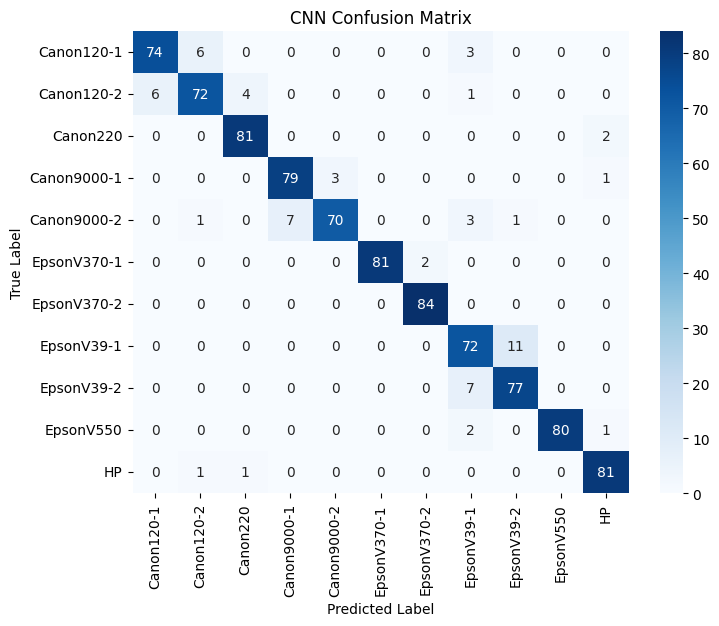

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")
plt.show()


**cnn_model prediction for individual image**

In [15]:
def predict_scanner(image_path):
    res=preprocess_image(image_path)
    res=res.reshape(1,256,256,1)

    probs=cnn.predict(res)[0]
    idx=np.argmax(probs)
    label=le.inverse_transform([idx])[0]
    confidence=probs[idx]
    return label,confidence

In [16]:
label,conf=predict_scanner("/kaggle/input/tracer/dataset-trace-2/dataset-trace-2/HP/300/s11_107.tif")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


In [17]:
print(label,conf)

HP 1.0
